# U-Net Segmentation Training - Google Colab Orchestrator

**Orchestrator only.** All training logic lives in the main repository files
(`train.py`, `utils/data_loading.py`, `unet/`, etc.). This notebook simply clones
the repo, installs dependencies, and calls into the existing code.

---

| Item | Value |
|------|-------|
| Source repo | `https://github.com/HaikalFK/segmentasi-unet.git` |
| Dataset | Plant Phenotyping (Kaggle) |
| Classes | 22 (auto-detected) |
| Runtime | **GPU** (T4, V100, or A100) |

---
## 1. Install Dependencies

PyTorch with CUDA is pre-installed in Colab. We only need to install
the project-specific dependencies from `requirements.txt`.

In [1]:
# Verify GPU is available
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU device: Tesla T4


In [2]:
# Clone the repository (clean clone from train_config branch)
import os
import shutil
from pathlib import Path

REPO_URL = 'https://github.com/HaikalFK/segmentasi-unet.git'
REPO_DIR = Path('/content/segmentasi-unet')

# Remove existing repo if any
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

print('Cloning repository...')
!git clone -b train_config {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')

Cloning repository...
Cloning into '/content/segmentasi-unet'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 141 (delta 54), reused 115 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 758.87 KiB | 29.19 MiB/s, done.
Resolving deltas: 100% (54/54), done.
Working directory: /content/segmentasi-unet


# Install project dependencies (version ranges to avoid build failures on Colab)
# PyTorch with CUDA is already pre-installed in Colab.
!pip install --quiet --upgrade pip
!pip install --quiet -r requirements.txt

# Verify imports
from utils.data_loading import BasicDataset
from unet import UNet
print('All imports OK')

In [3]:
!python data/download_dataset.py

Plant Phenotyping Dataset Downloader

Downloading... (this may take a while for large datasets)
Using Colab cache for faster access to the 'plant-phenotyping-dataset' dataset.
Dataset downloaded to: /kaggle/input/plant-phenotyping-dataset
Dataset root: /kaggle/input/plant-phenotyping-dataset/Plant_Phenotyping_Datasets

Organizing dataset into data/imgs/ and data/masks/

  Processing: Plant/Ara2012
    Found 120 RGB images
    Copied: 120 image/mask pairs, Skipped: 0 (no label)

  Processing: Plant/Ara2013-Canon
    Found 165 RGB images
    Copied: 165 image/mask pairs, Skipped: 0 (no label)

  Processing: Plant/Tobacco
    Found 62 RGB images
    Copied: 62 image/mask pairs, Skipped: 0 (no label)

  Total: 347 image/mask pairs copied

Verifying dataset
  Images: 347
  Masks:  347
  Matched pairs: 347

Done! Dataset is ready for training.
  Images: /content/segmentasi-unet/data/imgs  (347 files)
  Masks:  /content/segmentasi-unet/data/masks  (347 files)
  Matched pairs: 347

To train th

---
## 3. Training

Ada 2 opsi:
  1. **Training 1x** — langsung pakai konfigurasi di cell 6
  2. **Optuna tuning** — cari hyperparameter terbaik (lewati cell 6, langsung ke cell Optuna)

In [4]:
# ============================================================
# TRAINING CONFIGURATION
# Edit these values as needed.
# ============================================================
EPOCHS              = 100
BATCH_SIZE          = 8
SCALE               = 0.5
LEARNING_RATE       = 1e-5
VALIDATION          = 10.0
AMP                 = True
BILINEAR            = False
EARLY_STOP_PATIENCE = 15
EARLY_STOP_DELTA    = 0.001

print('Configuration:')
print(f'  Epochs:              {EPOCHS}')
print(f'  Batch:               {BATCH_SIZE}')
print(f'  Scale:               {SCALE}')
print(f'  AMP:                 {AMP}')
print(f'  Bilinear:            {BILINEAR}')
print(f'  Early stop patience: {EARLY_STOP_PATIENCE}')
print(f'  Early stop delta:    {EARLY_STOP_DELTA}')

Configuration:
  Epochs:              100
  Batch:               8
  Scale:               0.5
  AMP:                 True
  Bilinear:            False
  Early stop patience: 15
  Early stop delta:    0.001


In [5]:
from pathlib import Path
checkpoints = sorted(Path('checkpoints').glob('*.pth'))
print(f'Checkpoints found: {len(checkpoints)}')
for ckpt in checkpoints:
    size_mb = ckpt.stat().st_size / (1024 * 1024)
    print(f'  {ckpt.name}  ({size_mb:.2f} MB)')

Checkpoints found: 0


In [6]:
# Build and execute the training command
cmd = (
    f'python train.py'
    f' --classes 21'
    f' --epochs {EPOCHS}'
    f' --batch-size {BATCH_SIZE}'
    f' --scale {SCALE}'
    f' --learning-rate {LEARNING_RATE}'
    f' --validation {VALIDATION}'
    f' --early-stop-patience {EARLY_STOP_PATIENCE}'
    f' --early-stop-delta {EARLY_STOP_DELTA}'
)

if AMP:
    cmd += ' --amp'
if BILINEAR:
    cmd += ' --bilinear'

print(f'Command: {cmd}')
print('=' * 70)
!{cmd}

Command: python train.py --classes 21 --epochs 100 --batch-size 8 --scale 0.5 --learning-rate 1e-05 --validation 10.0 --early-stop-patience 15 --early-stop-delta 0.001 --amp
INFO: Using device cuda
INFO: Creating dataset with 347 examples
INFO: Scanning mask files to determine unique values
100% 347/347 [00:06<00:00, 51.51it/s]
INFO: Unique mask values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 27]
INFO: Detected 22 classes from mask files (override --classes 21)
INFO: Network:
	3 input channels
	22 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 347 examples
INFO: Scanning mask files to determine unique values
100% 347/347 [00:07<00:00, 46.25it/s]
INFO: Unique mask values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 27]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
]11;?]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set t

In [ ]:
# ============================================================
# ⚡ OPTUNA HYPERPARAMETER TUNING (opsional)
# Lewati cell ini kalau hanya mau training 1x.
# ============================================================
!pip install -q optuna

import optuna
import re
import subprocess
import shutil
from pathlib import Path

N_TRIALS = 10             # jumlah percobaan
EPOCHS_PER_TRIAL = 15     # epoch per trial (early stopping aktif)

# Hapus checkpoint lama biar tiap trial mulai bersih
if Path('checkpoints').exists():
    shutil.rmtree('checkpoints')

def objective(trial):
    # ── Hyperparameter search space ──
    lr = trial.suggest_float('lr', 5e-6, 5e-4, log=True)
    batch_size = trial.suggest_categorical('batch_size', [4, 8, 16])
    amp = trial.suggest_categorical('amp', [True, False])

    print(f'\n{"="*50}')
    print(f'Trial {trial.number}: lr={lr:.6f}, batch={batch_size}, amp={amp}')
    print(f'{"="*50}')

    # ── Panggil train.py via subprocess ──
    cmd = (
        f'python train.py'
        f' --epochs {EPOCHS_PER_TRIAL}'
        f' --batch-size {batch_size}'
        f' --learning-rate {lr:.8f}'
        f' --validation 10.0'
        f' --early-stop-patience 5'
    )
    if amp:
        cmd += ' --amp'

    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd='/content/segmentasi-unet')
    output = result.stdout + result.stderr

    # ── Parse Validation Dice dari output ──
    best_dice = 0.0
    for line in output.split('\n'):
        if 'New best model saved with Dice:' in line:
            m = re.search(r'Dice:\s+([\d.]+)', line)
            if m: best_dice = max(best_dice, float(m.group(1)))
        if 'Best validation Dice:' in line:
            m = re.search(r'Best validation Dice:\s+([\d.]+)', line)
            if m: best_dice = max(best_dice, float(m.group(1)))

    print(f'  → Trial {trial.number} Best Dice: {best_dice:.4f}')
    return best_dice

# ── Buat / lanjutkan study ──
study = optuna.create_study(
    direction='maximize',
    study_name='unet_tuning',
    storage='sqlite:///optuna_study.db',
    load_if_exists=True
)

print(f'\nMemulai Optuna dengan {N_TRIALS} trials...\n')
study.optimize(objective, n_trials=N_TRIALS)

# ── Hasil ──
print(f'\n{"="*60}')
print('OPTUNA COMPLETE!')
print(f'{"="*60}')
print(f'Best trial  : #{study.best_trial.number}')
print(f'Best Dice   : {study.best_value:.4f}')
print(f'Best params :')
for k, v in study.best_trial.params.items():
    print(f'  {k}: {v}')

[I 2026-07-30 09:37:47,582] A new study created in RDB with name: unet_tuning



Memulai Optuna dengan 10 trials...


Trial 0: lr=0.000017, batch=4, amp=False


[I 2026-07-30 09:40:03,203] Trial 0 finished with value: 0.4725 and parameters: {'lr': 1.723839494253435e-05, 'batch_size': 4, 'amp': False}. Best is trial 0 with value: 0.4725.


  → Trial 0 Best Dice: 0.4725

Trial 1: lr=0.000034, batch=4, amp=True


---
## 4.5 ⚖️ Loss Function Comparison (Standard BCE vs Weighted BCE + Dice)

Membandingkan **2 loss function** pada **U-Net standar** dengan hyperparameter identik:
- **standard_bce** : `CrossEntropyLoss` polos (baseline)
- **weighted_bce_dice** : Weighted BCE (inverse-frequency) + Dice Loss (metode)

Menjalankan `experiments/compare_losses.py` yang sudah ada di repo (terintegrasi W&B offline + minimal checkpoint). Output:
- `results/{loss}/` → `best_*.pth`, `config_*.yaml`, `metrics_*.json`
- `results/comparison/` → `metrics_comparison.csv`, `comparison_summary.md`, `loss_comparison.png`

> **Catatan branch:** Kode perbandingan ada di branch **`enhance_model`**. Kalau repo clone belum punya file-nya, jalankan dulu cell "sync branch" di bawah.

In [ ]:
# ============================================================
# ⚖️ JALANKAN LOSS FUNCTION COMPARISON
# ============================================================
# Memastikan file perbandingan tersedia (fallback dari branch enhance_model)
import subprocess
from pathlib import Path

NEED = [
    'experiments/compare_losses.py',
    'experiments/configs/standard_bce.yaml',
    'experiments/configs/weighted_bce_dice.yaml',
    'utils/loss_functions.py',
    'utils/checkpoint.py',
    'utils/wandb_tracker.py',
]

missing = [p for p in NEED if not Path('/content/segmentasi-unet').joinpath(p).exists()]
if missing:
    print(f'Mengambil file perbandingan dari branch enhance_model... ({len(missing)} file)')
    subprocess.run(['git', 'fetch', 'origin', 'enhance_model'], cwd='/content/segmentasi-unet', check=True)
    for p in NEED:
        subprocess.run(['git', 'checkout', 'origin/enhance_model', '--', p],
                       cwd='/content/segmentasi-unet')
else:
    print('Semua file perbandingan sudah tersedia.')

# Jalankan kedua eksperimen (standard_bce + weighted_bce_dice)
# Ubah --losses kalau mau jalankan satu saja; untuk quick-test turunkan epochs di config.
!python experiments/compare_losses.py --config-dir experiments/configs --output-dir results

In [ ]:
# ============================================================
# 📊 TAMPILKAN HASIL PERBANDINGAN LOSS
# ============================================================
import json, csv
from pathlib import Path
from tabulate import tabulate
from IPython.display import Image, display

COMPARE_DIR = Path('results/comparison')

# 1. Tabel metrik final (CSV yang dihasilkan compare_losses.py)
csv_path = COMPARE_DIR / 'metrics_comparison.csv'
if csv_path.exists():
    with open(csv_path, newline='') as f:
        rows = list(csv.DictReader(f))
    print('=' * 62)
    print('RESULT — LOSS FUNCTION COMPARISON (U-Net standar)')
    print('=' * 62)
    print(tabulate(rows, headers='keys', tablefmt='grid'))
    print('=' * 62)
    # Ringkas pemenang
    if len(rows) == 2:
        a, b = rows
        metric = 'best_val_dice'
        va, vb = float(a[metric]), float(b[metric])
        winner = a if va >= vb else b
        print(f'🏆 Winner (best val Dice): {winner["loss_function"]}'
              f' → Dice {float(winner[metric]):.4f} di epoch {winner["best_epoch"]}')
else:
    print('WARNING: metrics_comparison.csv belum ada. Jalankan cell perbandingan dulu.')

# 2. Plot learning curves
for name, title in [('loss_curves.png', 'Train Loss'),
                    ('dice_curves.png', 'Validation Dice'),
                    ('iou_curves.png', 'Validation IoU')]:
    p = COMPARE_DIR / name
    if p.exists():
        print(f'\n### {title}')
        display(Image(str(p)))
    else:
        print(f'\n### {title} — belum ada ({name})')

---
## 5. Evaluate Model (Custom - Full Metrics)

Run comprehensive evaluation: Dice Score, mIoU, Per-class IoU, and formatted table.

In [ ]:
# ============================================================
# CUSTOM EVALUATION - Full metrics in notebook
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from pathlib import Path
from tabulate import tabulate

from utils.data_loading import BasicDataset
from utils.dice_score import multiclass_dice_coeff, dice_coeff
from unet import UNet
from torch.utils.data import DataLoader, random_split

CHECKPOINT_PATH = 'checkpoints/checkpoint_best.pth'
SCALE = 0.5
BATCH_SIZE = 8
VALIDATION = 10.0
AMP = True
BILINEAR = False

# Load checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
mask_values = state_dict.pop('mask_values', [0, 1])
n_classes = len(mask_values)

print(f'Checkpoint: {CHECKPOINT_PATH}')
print(f'Classes: {n_classes} (mask_values: {mask_values})')
print(f'Device: {device}')

# Create model
net = UNet(n_channels=3, n_classes=n_classes, bilinear=BILINEAR)
net.to(device=device)
net.load_state_dict(state_dict)
net.eval()

# Create validation dataset — langsung BasicDataset (tanpa suffix _mask)
dataset = BasicDataset('./data/imgs/', './data/masks/', SCALE, target_size=(256, 256))
dataset.mask_values = mask_values

n_val = int(len(dataset) * VALIDATION / 100)
n_train = len(dataset) - n_val
_, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))

val_loader = DataLoader(val_set, shuffle=False, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True, drop_last=True)
print(f'Validation samples: {len(val_set)}')
print('-' * 60)

# Evaluation
dice_score = 0.0
total_iou_per_class = None
total_mean_iou = 0.0
num_batches = 0

with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=AMP):
    for batch in tqdm(val_loader, desc='Evaluating', unit='batch'):
        image, mask_true = batch['image'], batch['mask']
        image = image.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
        mask_true = mask_true.to(device=device, dtype=torch.long)

        with torch.no_grad():
            mask_pred = net(image)

        if n_classes == 1:
            mask_pred = (F.sigmoid(mask_pred) > 0.5).float()
            dice_score += dice_coeff(mask_pred, mask_true.float(), reduce_batch_first=False).item()
        else:
            mask_true_oh = F.one_hot(mask_true, n_classes).permute(0, 3, 1, 2).float()
            mask_pred_oh = F.one_hot(mask_pred.argmax(dim=1), n_classes).permute(0, 3, 1, 2).float()
            
            # Dice (excl background)
            dice_score += multiclass_dice_coeff(mask_pred_oh[:, 1:], mask_true_oh[:, 1:], reduce_batch_first=False).item()

            # IoU per class (excl background)
            pred_masks = mask_pred.argmax(dim=1)
            true_masks = mask_true

            # Convert to one-hot for IoU
            pred_oh = F.one_hot(pred_masks, n_classes).permute(0, 3, 1, 2).float()
            true_oh = F.one_hot(true_masks, n_classes).permute(0, 3, 1, 2).float()

            # Exclude background (class 0)
            pred_oh = pred_oh[:, 1:]
            true_oh = true_oh[:, 1:]

            intersection = (pred_oh * true_oh).sum(dim=(0, 2, 3))
            union = pred_oh.sum(dim=(0, 2, 3)) + true_oh.sum(dim=(0, 2, 3)) - intersection
            iou = intersection / (union + 1e-8)
            mean_iou = iou.mean()

            if total_iou_per_class is None:
                total_iou_per_class = iou.detach().cpu()
            else:
                total_iou_per_class += iou.detach().cpu()
            total_mean_iou += mean_iou.item()

        num_batches += 1

avg_dice = dice_score / num_batches
avg_iou_per_class = total_iou_per_class / num_batches if total_iou_per_class is not None else None
avg_mean_iou = total_mean_iou / num_batches if num_batches > 0 else 0.0

# ============================================================
# PRINT RESULTS
# ============================================================
print('\n' + '=' * 70)
print('EVALUATION RESULTS')
print('=' * 70)
print(f'Dice Score (excl. background): {avg_dice:.4f}')
print(f'Mean IoU (excl. background):   {avg_mean_iou:.4f}')
print('-' * 70)
if avg_iou_per_class is not None:
    print('IoU per class (excl. background):')
    table_data = []
    for i, iou in enumerate(avg_iou_per_class):
        class_idx = i + 1  # skip background
        class_val = mask_values[class_idx] if class_idx < len(mask_values) else class_idx
        table_data.append([f'Class {class_val}', f'{iou:.4f}'])
    print(tabulate(table_data, headers=['Class', 'IoU'], tablefmt='grid'))
print('=' * 70)

# Also return as dict for potential further use
results = {
    'dice': avg_dice,
    'mean_iou': avg_mean_iou,
    'iou_per_class': avg_iou_per_class.tolist() if avg_iou_per_class is not None else None,
}
results

Checkpoint: checkpoints/checkpoint_best.pth
Classes: 22 (mask_values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 27])
Device: cuda


100%|██████████| 347/347 [00:07<00:00, 48.54it/s]


Validation samples: 34
------------------------------------------------------------


Evaluating: 100%|██████████| 4/4 [00:02<00:00,  1.62batch/s]


EVALUATION RESULTS
Dice Score (excl. background): 0.4716
Mean IoU (excl. background):   0.0094
----------------------------------------------------------------------
IoU per class (excl. background):
+----------+--------+
| Class    |    IoU |
+==========+========+
| Class 1  | 0.0005 |
+----------+--------+
| Class 2  | 0      |
+----------+--------+
| Class 3  | 0      |
+----------+--------+
| Class 4  | 0.0878 |
+----------+--------+
| Class 5  | 0.109  |
+----------+--------+
| Class 6  | 0      |
+----------+--------+
| Class 7  | 0      |
+----------+--------+
| Class 8  | 0      |
+----------+--------+
| Class 9  | 0      |
+----------+--------+
| Class 10 | 0      |
+----------+--------+
| Class 11 | 0      |
+----------+--------+
| Class 12 | 0      |
+----------+--------+
| Class 13 | 0      |
+----------+--------+
| Class 14 | 0      |
+----------+--------+
| Class 15 | 0      |
+----------+--------+
| Class 16 | 0      |
+----------+--------+
| Class 17 | 0      |
+------

{'dice': 0.4715747609734535,
 'mean_iou': 0.009396466077305377,
 'iou_per_class': [0.0005480557447299361,
  0.0,
  0.0,
  0.08779701590538025,
  0.10898071527481079,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0]}

In [ ]:
# ============================================================
# 📈 LEARNING CURVE — Visualisasi Performa per Epoch
# Mengevaluasi ulang setiap checkpoint_epoch*.pth untuk
# melihat perkembangan Dice & mIoU selama training.
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import OrderedDict

from utils.data_loading import BasicDataset
from utils.dice_score import multiclass_dice_coeff
from unet import UNet
from torch.utils.data import DataLoader, random_split

# ── Konfigurasi ──
CKPT_DIR = Path('checkpoints')
SCALE = 0.5
BATCH_SIZE = 8
VALIDATION = 10.0
AMP = True
BILINEAR = False
OUTPUT_IMG = 'learning_curve.png'

# ── Siapkan validation dataset (sama persis dengan training) ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ambil mask_values dari checkpoint_best.pth untuk konsistensi
best_state = torch.load(str(CKPT_DIR / 'checkpoint_best.pth'), map_location='cpu')
mask_values = best_state.pop('mask_values', [0, 1])
n_classes = len(mask_values)
print(f'Classes: {n_classes}, Mask values: {mask_values}')

dataset = BasicDataset('./data/imgs/', './data/masks/', SCALE, target_size=(256, 256))
dataset.mask_values = mask_values

n_val = int(len(dataset) * VALIDATION / 100)
n_train = len(dataset) - n_val
_, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_set, shuffle=False, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True, drop_last=True)
print(f'Validation samples: {len(val_set)}')

# ── Cari semua checkpoint epoch ──
ckpt_files = sorted(CKPT_DIR.glob('checkpoint_epoch*.pth'),
                    key=lambda p: int(p.stem.split('epoch')[1]))
print(f'Checkpoints ditemukan: {len(ckpt_files)}')

# ── Evaluasi setiap checkpoint ──
epochs = []
dice_scores = []
mean_ious = []

for ckpt_path in ckpt_files:
    epoch_num = int(ckpt_path.stem.split('epoch')[1])
    epochs.append(epoch_num)

    # Load model
    state = torch.load(str(ckpt_path), map_location=device)
    _ = state.pop('mask_values', None)
    net = UNet(n_channels=3, n_classes=n_classes, bilinear=BILINEAR)
    net.to(device=device)
    net.load_state_dict(state)
    net.eval()

    # Evaluate
    total_dice = 0.0
    total_miou = 0.0
    num_batches = 0

    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=AMP):
        for batch in tqdm(val_loader, desc=f'Epoch {epoch_num}', unit='batch', leave=False):
            image, mask_true = batch['image'], batch['mask']
            image = image.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            mask_true = mask_true.to(device=device, dtype=torch.long)

            with torch.no_grad():
                mask_pred = net(image)

            # Dice (excl background)
            mask_true_oh = F.one_hot(mask_true, n_classes).permute(0, 3, 1, 2).float()
            mask_pred_oh = F.one_hot(mask_pred.argmax(dim=1), n_classes).permute(0, 3, 1, 2).float()
            total_dice += multiclass_dice_coeff(mask_pred_oh[:, 1:], mask_true_oh[:, 1:], reduce_batch_first=False).item()

            # mIoU (excl background)
            pred_oh = F.one_hot(mask_pred.argmax(dim=1), n_classes).permute(0, 3, 1, 2).float()[:, 1:]
            true_oh = F.one_hot(mask_true, n_classes).permute(0, 3, 1, 2).float()[:, 1:]
            intersection = (pred_oh * true_oh).sum(dim=(0, 2, 3))
            union = pred_oh.sum(dim=(0, 2, 3)) + true_oh.sum(dim=(0, 2, 3)) - intersection
            total_miou += (intersection / (union + 1e-8)).mean().item()
            num_batches += 1

    avg_dice = total_dice / num_batches
    avg_miou = total_miou / num_batches
    dice_scores.append(avg_dice)
    mean_ious.append(avg_miou)

    print(f'  Epoch {epoch_num:2d} → Dice: {avg_dice:.4f}  |  mIoU: {avg_miou:.4f}')

# ── Tambahkan checkpoint_best (jika beda dari epoch terakhir) ──
best_path = CKPT_DIR / 'checkpoint_best.pth'
if best_path.exists() and best_path not in ckpt_files:
    state = torch.load(str(best_path), map_location=device)
    _ = state.pop('mask_values', None)
    net = UNet(n_channels=3, n_classes=n_classes, bilinear=BILINEAR)
    net.to(device=device)
    net.load_state_dict(state)
    net.eval()

    total_dice = 0.0
    total_miou = 0.0
    num_batches = 0
    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=AMP):
        for batch in tqdm(val_loader, desc='Best', unit='batch', leave=False):
            image, mask_true = batch['image'], batch['mask']
            image = image.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            mask_true = mask_true.to(device=device, dtype=torch.long)
            with torch.no_grad():
                mask_pred = net(image)
            mask_true_oh = F.one_hot(mask_true, n_classes).permute(0, 3, 1, 2).float()
            mask_pred_oh = F.one_hot(mask_pred.argmax(dim=1), n_classes).permute(0, 3, 1, 2).float()
            total_dice += multiclass_dice_coeff(mask_pred_oh[:, 1:], mask_true_oh[:, 1:], reduce_batch_first=False).item()
            pred_oh = F.one_hot(mask_pred.argmax(dim=1), n_classes).permute(0, 3, 1, 2).float()[:, 1:]
            true_oh = F.one_hot(mask_true, n_classes).permute(0, 3, 1, 2).float()[:, 1:]
            intersection = (pred_oh * true_oh).sum(dim=(0, 2, 3))
            union = pred_oh.sum(dim=(0, 2, 3)) + true_oh.sum(dim=(0, 2, 3)) - intersection
            total_miou += (intersection / (union + 1e-8)).mean().item()
            num_batches += 1
    print(f'  BEST     → Dice: {total_dice/num_batches:.4f}  |  mIoU: {total_miou/num_batches:.4f}  ★')

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dice Score
ax1.plot(epochs, dice_scores, 'o-', color='#2E86AB', linewidth=2, markersize=8)
ax1.set_title('Dice Score per Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Dice Score', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(dice_scores) * 1.2 + 0.05)
# Annotate values
for x, y in zip(epochs, dice_scores):
    ax1.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='#2E86AB')

# Mean IoU
ax2.plot(epochs, mean_ious, 's-', color='#A23B72', linewidth=2, markersize=8)
ax2.set_title('Mean IoU per Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mean IoU', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(mean_ious) * 1.5 + 0.01)
for x, y in zip(epochs, mean_ious):
    ax2.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='#A23B72')

plt.suptitle('Learning Curve — U-Net Plant Phenotyping', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan
plt.savefig(OUTPUT_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Learning curve saved ke {OUTPUT_IMG}')

Checkpoint: checkpoints/checkpoint_best.pth
Classes: 22
Mask values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 27]
Device: cuda

Input: data/imgs/ara2012_plant003.png (245x264)
Prediction saved to: outputs/ara2012_plant003_OUT.png

Ground truth: data/masks/ara2012_plant003.png
Mean IoU (excl. background): 0.0005
--------------------------------------------------
IoU per class:
+----------+--------+
| Class    |    IoU |
+==========+========+
| Class 1  | 0      |
+----------+--------+
| Class 2  | 0      |
+----------+--------+
| Class 3  | 0      |
+----------+--------+
| Class 4  | 0.0102 |
+----------+--------+
| Class 5  | 0      |
+----------+--------+
| Class 6  | 0      |
+----------+--------+
| Class 7  | 0      |
+----------+--------+
| Class 8  | 0      |
+----------+--------+
| Class 9  | 0      |
+----------+--------+
| Class 10 | 0      |
+----------+--------+
| Class 11 | 0      |
+----------+--------+
| Class 12 | 0      |
+----------+---

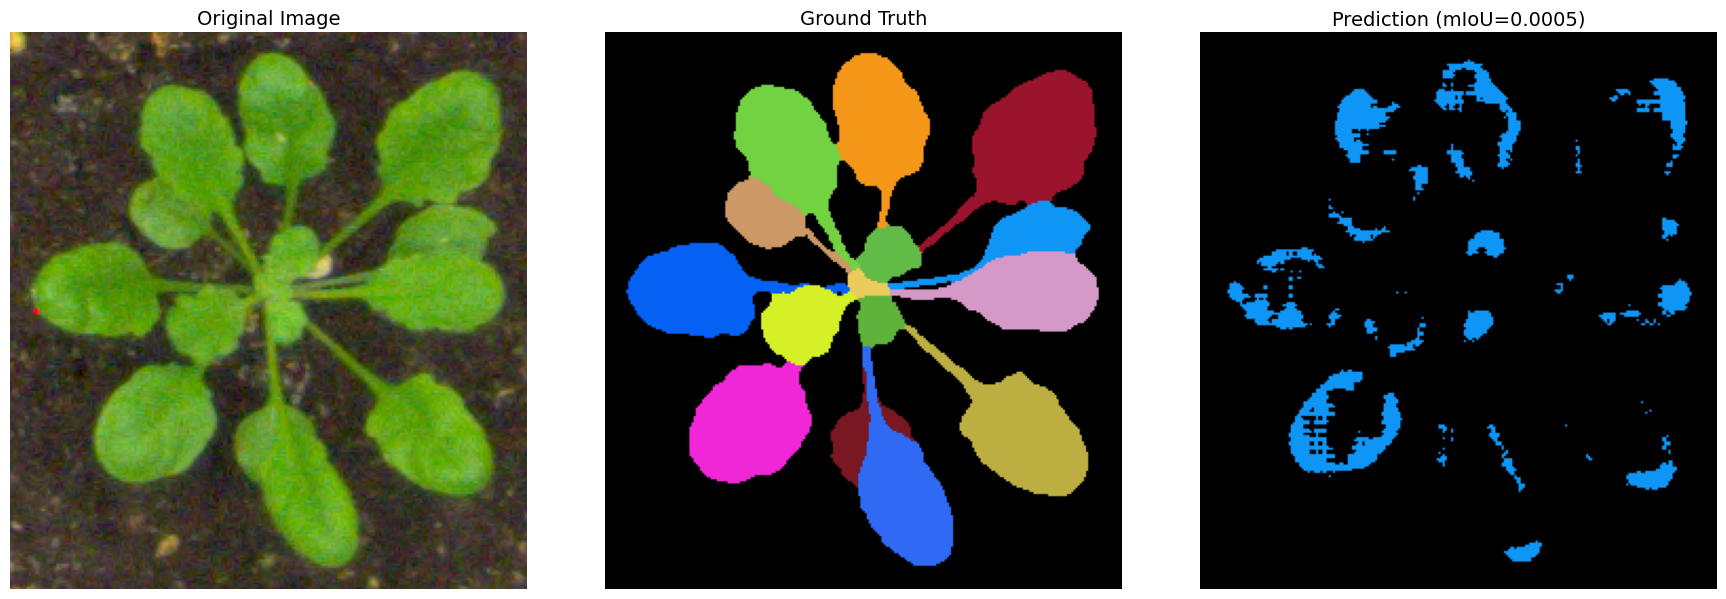


Done! Output saved to outputs/


In [ ]:
# ============================================================
# CUSTOM PREDICTION - Full visualization with IoU
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tabulate import tabulate

from utils.data_loading import BasicDataset
from unet import UNet

# Config
CHECKPOINT_PATH = 'checkpoints/checkpoint_best.pth'
SAMPLE_IMAGE = 'data/imgs/ara2012_plant003.png'
SCALE = 0.5
BILINEAR = False
OUTPUT_DIR = 'outputs'

# Load checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
mask_values = state_dict.pop('mask_values', [0, 1])
n_classes = len(mask_values)

print(f'Checkpoint: {CHECKPOINT_PATH}')
print(f'Classes: {n_classes}')
print(f'Mask values: {mask_values}')
print(f'Device: {device}')

# Create model
net = UNet(n_channels=3, n_classes=n_classes, bilinear=BILINEAR)
net.to(device=device)
net.load_state_dict(state_dict)
net.eval()

# Load image
img = Image.open(SAMPLE_IMAGE).convert('RGB')
print(f'\nInput: {SAMPLE_IMAGE} ({img.size[0]}x{img.size[1]})')

# Preprocess & Predict
img_tensor = torch.from_numpy(BasicDataset.preprocess(None, img, SCALE, is_mask=False))
img_tensor = img_tensor.unsqueeze(0).to(device=device, dtype=torch.float32)

with torch.no_grad():
    output = net(img_tensor)
    output = F.interpolate(output, (img.size[1], img.size[0]), mode='bilinear', align_corners=False)
    if n_classes > 1:
        pred_mask = output.argmax(dim=1)[0].cpu().numpy()
    else:
        pred_mask = (F.sigmoid(output) > 0.5).float()[0, 0].cpu().numpy()

# Save prediction
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_name = Path(SAMPLE_IMAGE).stem + '_OUT.png'
out_path = Path(OUTPUT_DIR) / out_name

def mask_to_image(mask, mask_values):
    out = np.zeros((mask.shape[-2], mask.shape[-1]), dtype=np.uint8)
    for i, v in enumerate(mask_values):
        out[mask == i] = v
    return Image.fromarray(out)

result_img = mask_to_image(pred_mask, mask_values)
result_img.save(out_path)
print(f'Prediction saved to: {out_path}')

# ============================================================
# COMPUTE IoU vs GROUND TRUTH (if available)
# ============================================================
mask_dir = 'data/masks/'
base_name = Path(SAMPLE_IMAGE).stem
mask_path = Path(mask_dir) / (base_name + '.png')

iou_per_class = None
mean_iou = None

if mask_path.exists():
    true_mask = np.array(Image.open(mask_path))
    
    # Compute IoU — convert to LongTensor first (one_hot requires Long)
    pred_tensor = torch.from_numpy(pred_mask).long()
    true_tensor = torch.from_numpy(true_mask).long()
    
    pred_oh = F.one_hot(pred_tensor, n_classes).permute(2, 0, 1).float()
    true_oh = F.one_hot(true_tensor, n_classes).permute(2, 0, 1).float()
    
    # Exclude background (class 0)
    pred_oh = pred_oh[1:]
    true_oh = true_oh[1:]
    
    intersection = (pred_oh * true_oh).sum(dim=(1, 2))
    union = pred_oh.sum(dim=(1, 2)) + true_oh.sum(dim=(1, 2)) - intersection
    iou = intersection / (union + 1e-8)
    iou_per_class = iou.numpy()
    mean_iou = iou.mean().item()
    
    print(f'\nGround truth: {mask_path}')
    print(f'Mean IoU (excl. background): {mean_iou:.4f}')
    print('-' * 50)
    print('IoU per class:')
    table_data = []
    for i, iou_val in enumerate(iou_per_class):
        class_idx = i + 1
        class_val = mask_values[class_idx] if class_idx < len(mask_values) else class_idx
        table_data.append([f'Class {class_val}', f'{iou_val:.4f}'])
    print(tabulate(table_data, headers=['Class', 'IoU'], tablefmt='grid'))
else:
    print(f'\nNo ground truth found at {mask_path} - skipping IoU computation')

# ============================================================
# VISUALIZATION
# ============================================================
# Create color palette for visualization
def create_color_palette(n_classes):
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(n_classes, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # background = black
    return colors

colors = create_color_palette(n_classes)

def mask_to_rgb(mask, colors):
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for i in range(len(colors)):
        rgb[mask == i] = colors[i]
    return rgb

pred_rgb = mask_to_rgb(pred_mask, colors)

# Load ground truth if exists for visualization
if mask_path.exists():
    true_rgb = mask_to_rgb(true_mask, colors)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img)
    axes[0].set_title('Original Image', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(true_rgb)
    axes[1].set_title(f'Ground Truth', fontsize=14)
    axes[1].axis('off')
    
    axes[2].imshow(pred_rgb)
    axes[2].set_title(f'Prediction (mIoU={mean_iou:.4f})', fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img)
    axes[0].set_title('Original Image', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(pred_rgb)
    axes[1].set_title('Prediction', fontsize=14)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

print(f'\nDone! Output saved to {OUTPUT_DIR}/')

In [ ]:
dir_path_model = Path('checkpoints')
dir_path_model

: 